<a href="https://colab.research.google.com/github/nehansa2003/Weather-Forecasting-Project/blob/main/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display




In [2]:
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
dataset='/content/drive/MyDrive/Capstone_Datasets/weather_data_processed_2020_2025.parquet'

In [4]:
# Load Parquet dataset
weather_df = pd.read_parquet(
    dataset,
    engine="pyarrow"
)

print("Dataset loaded successfully!")

print("\nShape:")
print(weather_df.shape)

print("\nColumns:")
print(weather_df.columns.tolist())

print("\nDate range:")
print(weather_df["datetime"].min())
print("to")
print(weather_df["datetime"].max())

print("\nDistricts:")
print(weather_df["district"].unique())

print("\nGeographical points:")
print(weather_df["global_pointid"].nunique())

display(weather_df.head())

Dataset loaded successfully!

Shape:
(5629056, 34)

Columns:
['district', 'pointid', 'global_pointid', 'latitude', 'longitude', 'elevation_m', 'datetime', 'date', 'day', 'month', 'year', 'time', 'season', 'hour', 'day_of_week', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temperature_c', 'feelslike_c', 'humidity_pct', 'dewpoint_c', 'pressure_hpa', 'windspeed_kmh', 'winddirection_deg', 'winddirection_compass', 'windgust_kmh', 'rainfall_mm', 'cloudcover_pct', 'solarradiation_wm2', 'sunshineduration_s']

Date range:
2020-01-01 00:00:00
to
2025-12-31 23:00:00

Districts:
['Colombo' 'Galle' 'Gampaha' 'Jaffna' 'Kandy']

Geographical points:
107


,district,pointid,global_pointid,latitude,longitude,elevation_m,datetime,date,day,month,...,dewpoint_c,pressure_hpa,windspeed_kmh,winddirection_deg,winddirection_compass,windgust_kmh,rainfall_mm,cloudcover_pct,solarradiation_wm2,sunshineduration_s
0,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 00:00:00,2020-01-01,1,1,...,24.0,1012.2,9.0,157,SSE,22.0,0.1,43,0.0,0.0
1,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 01:00:00,2020-01-01,1,1,...,23.9,1011.7,5.5,148,SSE,15.8,0.0,50,0.0,0.0
2,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 02:00:00,2020-01-01,1,1,...,24.0,1011.1,4.3,156,SSE,9.7,0.1,78,0.0,0.0
3,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 03:00:00,2020-01-01,1,1,...,23.9,1010.4,3.9,146,SE,8.6,0.1,92,0.0,0.0
4,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 04:00:00,2020-01-01,1,1,...,23.8,1010.5,3.6,96,E,7.2,0.0,90,0.0,0.0


Variable Information

In [5]:
variable_info = pd.DataFrame({
    "Column": weather_df.columns,
    "Data_Type": weather_df.dtypes.astype(str),
    "Non_Null_Count": weather_df.notna().sum().values,
    "Missing_Count": weather_df.isna().sum().values,
    "Missing_Percentage": (
        weather_df.isna().mean().values * 100
    ),
    "Unique_Values": weather_df.nunique().values
})

display(variable_info)

,Column,Data_Type,Non_Null_Count,Missing_Count,Missing_Percentage,Unique_Values
district,district,object,5629056,0,0.0,5
pointid,pointid,int64,5629056,0,0.0,33
global_pointid,global_pointid,object,5629056,0,0.0,107
latitude,latitude,float64,5629056,0,0.0,27
longitude,longitude,float64,5629056,0,0.0,29
elevation_m,elevation_m,float64,5629056,0,0.0,66
datetime,datetime,datetime64[ns],5629056,0,0.0,52608
date,date,object,5629056,0,0.0,2192
day,day,int64,5629056,0,0.0,31
month,month,int64,5629056,0,0.0,12


Descriptive statistics

In [6]:
numeric_columns = weather_df.select_dtypes(
    include=np.number
).columns

descriptive_stats = (
    weather_df[numeric_columns]
    .describe()
    .T
)

descriptive_stats["missing"] = (
    weather_df[numeric_columns]
    .isna()
    .sum()
)

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,missing
pointid,5629056.0,1.278505e+01,8.466568,1.00000,6.000000,1.100000e+01,18.000000,33.00000,0
latitude,5629056.0,7.263026e+00,1.155496,5.84691,6.191230,7.130690e+00,7.386550,9.75914,0
longitude,5629056.0,8.024512e+01,0.296227,79.72583,79.996570,8.015175e+01,80.536970,80.79491,0
elevation_m,5629056.0,2.081963e+02,330.875121,0.00000,1.000000,2.400000e+01,427.000000,1565.00000,0
day,5629056.0,1.573266e+01,8.801371,1.00000,8.000000,1.600000e+01,23.000000,31.00000,0
month,5629056.0,6.521898e+00,3.448987,1.00000,4.000000,7.000000e+00,10.000000,12.00000,0
year,5629056.0,2.022500e+03,1.708181,2020.00000,2021.000000,2.022500e+03,2024.000000,2025.00000,0
hour,5629056.0,1.150000e+01,6.922187,0.00000,5.750000,1.150000e+01,17.250000,23.00000,0
day_of_week,5629056.0,2.999544e+00,1.999658,0.00000,1.000000,3.000000e+00,5.000000,6.00000,0
day_of_year,5629056.0,1.831670e+02,105.462791,1.00000,92.000000,1.830000e+02,274.250000,366.00000,0


District-level dataset distribution

In [7]:
district_records = (
    weather_df
    .groupby("district")
    .size()
    .sort_values(ascending=False)
)

display(
    district_records.to_frame("Record_Count")
)

,Record_Count
district,
Kandy,1736064
Galle,1525632
Gampaha,894336
Jaffna,894336
Colombo,578688


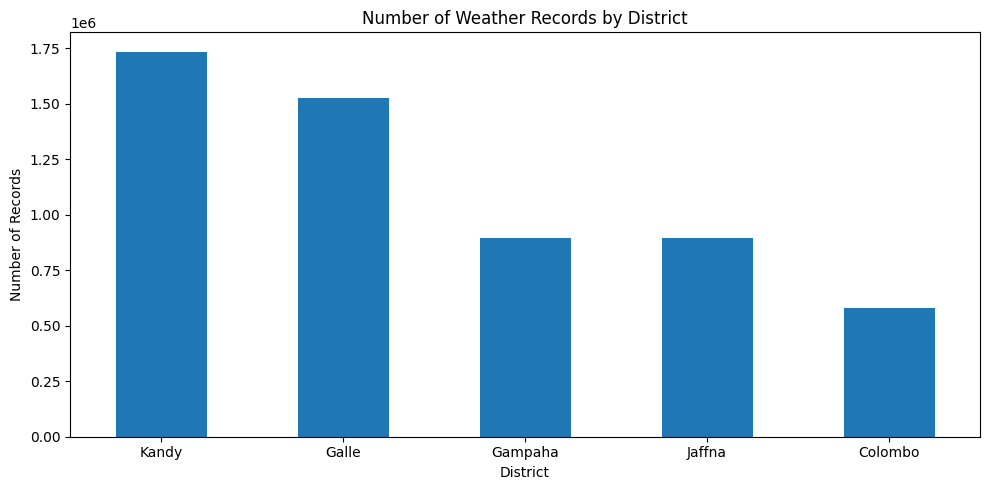

In [8]:
plt.figure(figsize=(10, 5))

district_records.plot(kind="bar")

plt.title("Number of Weather Records by District")
plt.xlabel("District")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Geographical point distribution

In [9]:
point_counts = (
    weather_df
    .groupby("district")["global_pointid"]
    .nunique()
)

display(
    point_counts.to_frame("Number_of_Points")
)

,Number_of_Points
district,
Colombo,11
Galle,29
Gampaha,17
Jaffna,17
Kandy,33


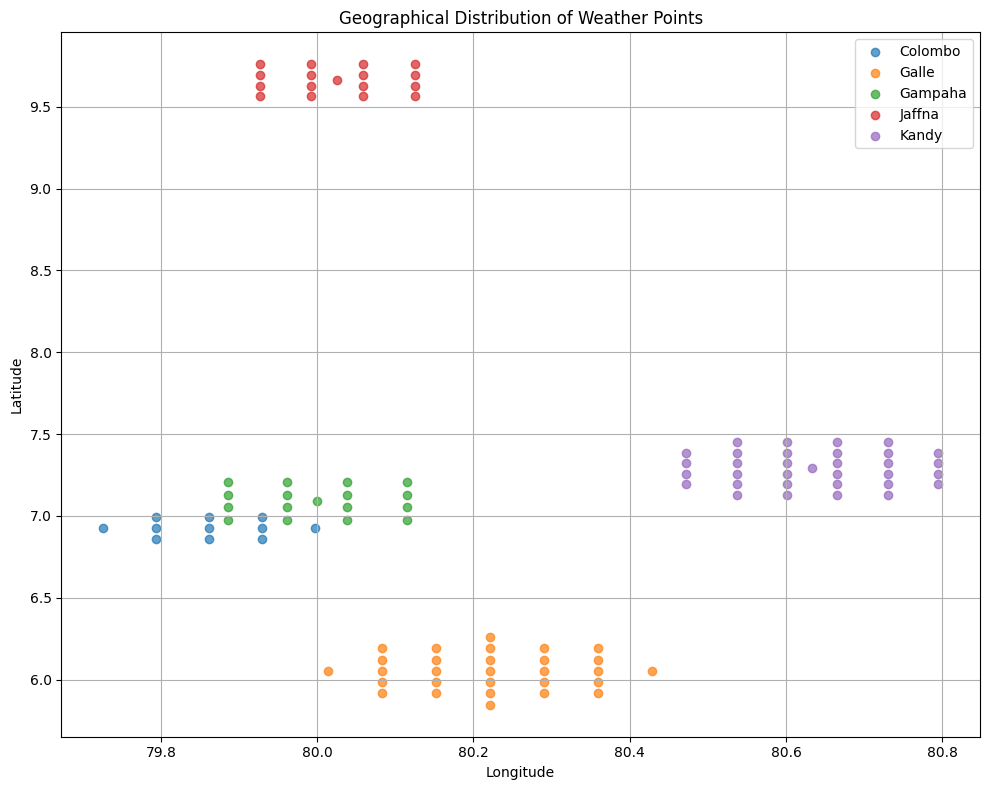

In [10]:
plt.figure(figsize=(10, 8))

for district in weather_df["district"].unique():

    subset = weather_df[
        weather_df["district"] == district
    ].drop_duplicates("global_pointid")

    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        label=district,
        alpha=0.7
    )

plt.title("Geographical Distribution of Weather Points")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

Verify hourly frequency

In [11]:
time_differences = (
    weather_df
    .sort_values(
        ["global_pointid", "datetime"]
    )
    .groupby("global_pointid")["datetime"]
    .diff()
)

print("Time difference distribution:")

display(
    time_differences
    .value_counts()
    .head(10)
)

Time difference distribution:


,count
datetime,
0 days 01:00:00,5628949


Identify missing hourly observations

In [12]:
sorted_df = weather_df.sort_values(
    ["global_pointid", "datetime"]
)

time_diff = (
    sorted_df
    .groupby("global_pointid")["datetime"]
    .diff()
)

missing_intervals = (
    time_diff[
        time_diff > pd.Timedelta(hours=1)
    ]
)

print(
    "Number of gaps greater than 1 hour:",
    len(missing_intervals)
)

Number of gaps greater than 1 hour: 0


Largest temporal gaps

In [13]:
gap_info = sorted_df.copy()

gap_info["time_gap"] = (
    gap_info
    .groupby("global_pointid")["datetime"]
    .diff()
)

largest_gaps = (
    gap_info[
        gap_info["time_gap"] > pd.Timedelta(hours=1)
    ]
    [
        [
            "district",
            "global_pointid",
            "datetime",
            "time_gap"
        ]
    ]
    .sort_values(
        "time_gap",
        ascending=False
    )
)

display(
    largest_gaps.head(20)
)

,district,global_pointid,datetime,time_gap


Elevation analysis

In [14]:
elevation_summary = (
    weather_df
    .groupby("district")["elevation_m"]
    .agg(
        mean="mean",
        minimum="min",
        maximum="max"
    )
)

display(elevation_summary)

,mean,minimum,maximum
district,,,
Colombo,6.545455,0.0,24.0
Galle,21.931034,0.0,108.0
Gampaha,23.411765,2.0,44.0
Jaffna,3.058824,0.0,12.0
Kandy,639.969697,191.0,1565.0


Weather variable distributions

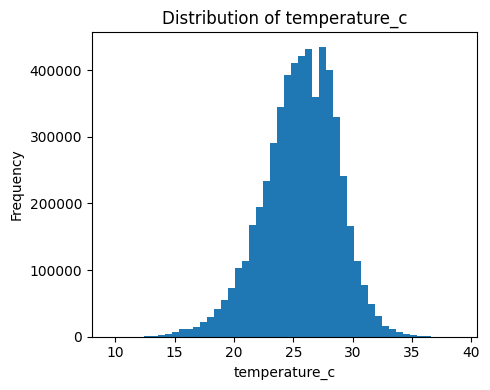

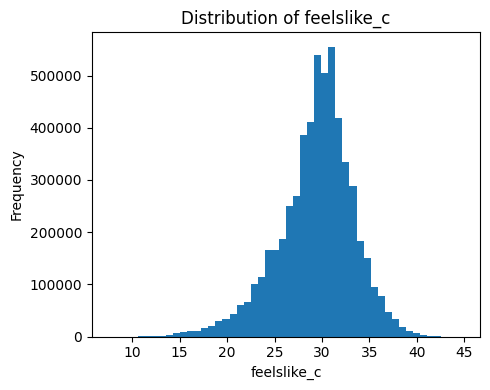

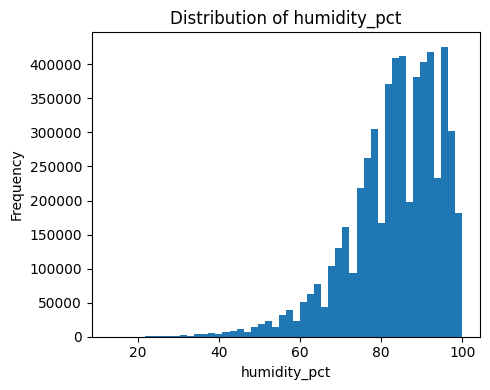

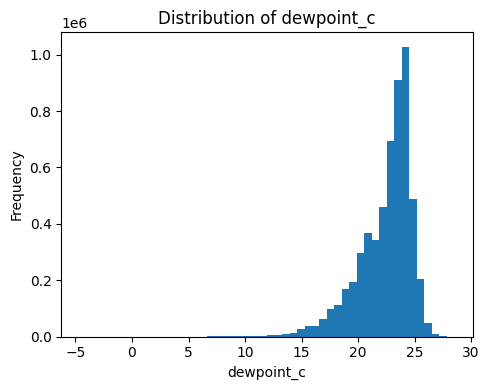

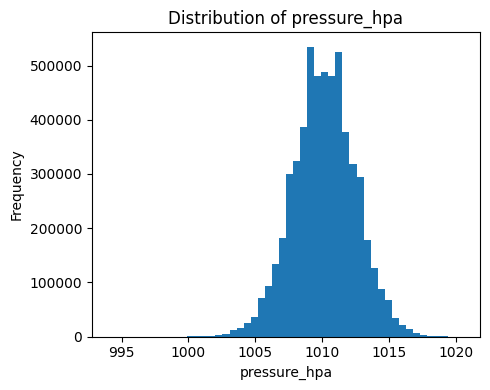

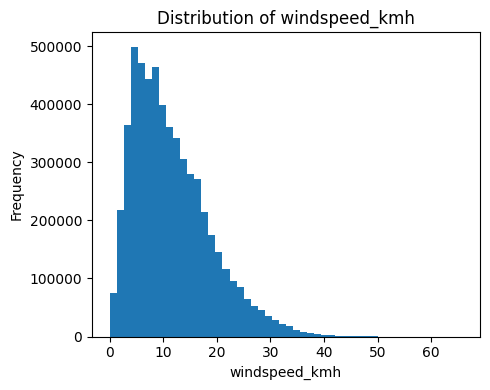

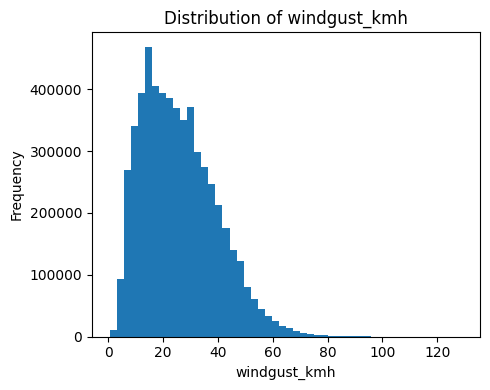

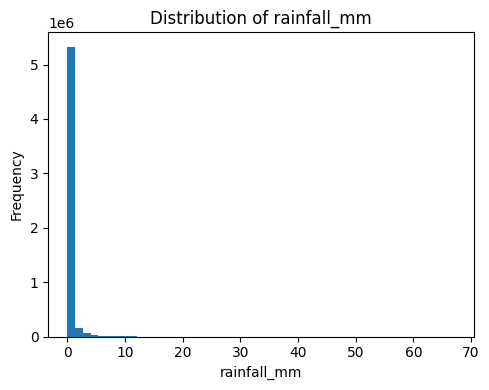

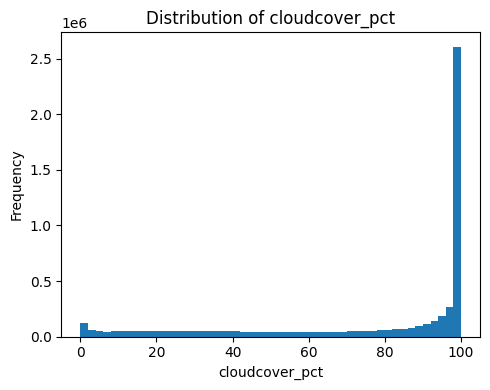

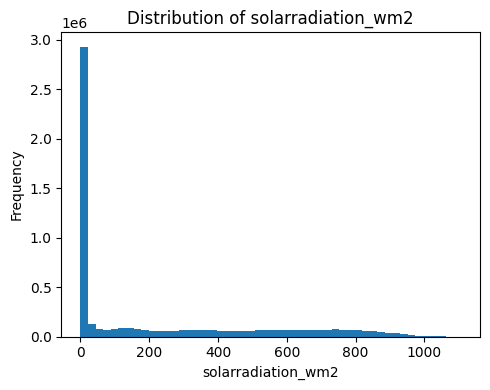

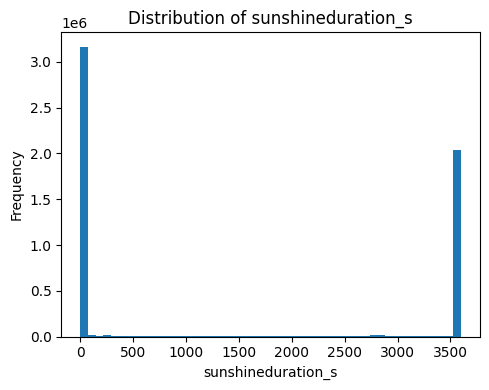

In [15]:
weather_variables = [
    "temperature_c",
    "feelslike_c",
    "humidity_pct",
    "dewpoint_c",
    "pressure_hpa",
    "windspeed_kmh",
    "windgust_kmh",
    "rainfall_mm",
    "cloudcover_pct",
    "solarradiation_wm2",
    "sunshineduration_s"
]

for column in weather_variables:

    if column not in weather_df.columns:
        continue

    plt.figure(figsize=(5, 4))

    plt.hist(
        weather_df[column].dropna(),
        bins=50
    )

    plt.title(
        f"Distribution of {column}"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

Rainfall occurrence

In [16]:
rain_count = pd.Series(
    np.where(
        weather_df["rainfall_mm"] > 0,
        "Rain",
        "No Rain"
    )
).value_counts()

display(
    rain_count.to_frame(
        "Count"
    )
)

#Percentage
rain_percentage = (
    rain_count /
    rain_count.sum()
    * 100
)

display(
    rain_percentage.to_frame(
        "Percentage"
    )
)

,Count
No Rain,3335599
Rain,2293457


,Percentage
No Rain,59.25681
Rain,40.74319


Rainfall distribution

this distribution should be like create sub plots for each district and data should show as bar graphs in each hour of the day. by getting mean for whole 2020-2025

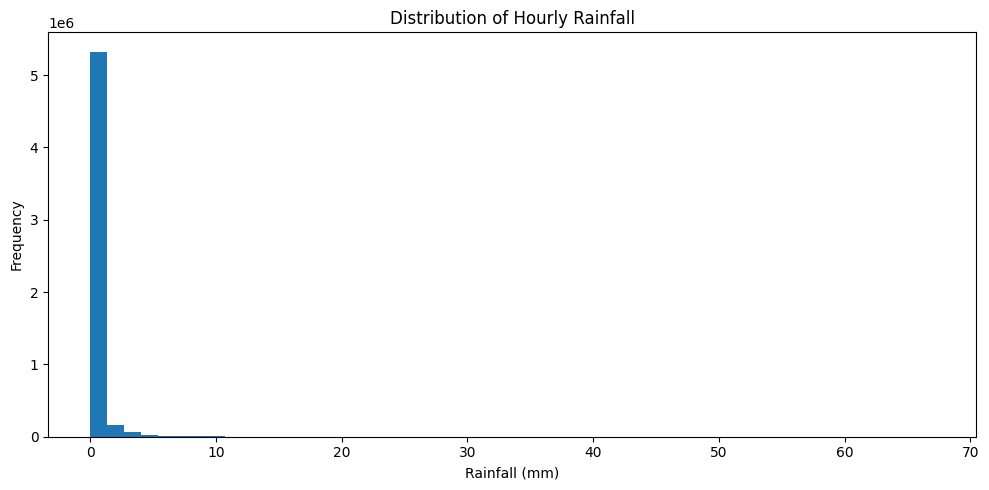

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    weather_df["rainfall_mm"].dropna(),
    bins=50
)

plt.title(
    "Distribution of Hourly Rainfall"
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

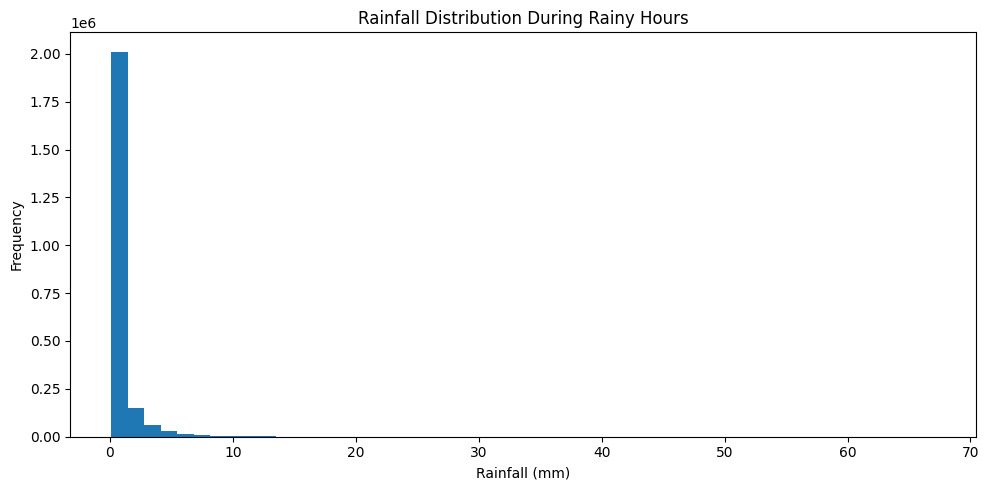

In [ ]:
rainy_hours = weather_df[
    weather_df["rainfall_mm"] > 0
]

plt.figure(figsize=(10, 5))

plt.hist(
    rainy_hours["rainfall_mm"],
    bins=50
)

plt.title(
    "Rainfall Distribution During Rainy Hours"
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Hourly weather patterns

In [17]:
hourly_summary = (
    weather_df
    .groupby("hour")
    [
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "rainfall_mm",
            "cloudcover_pct",
            "solarradiation_wm2"
        ]
    ]
    .mean()
)

display(hourly_summary)

,temperature_c,humidity_pct,pressure_hpa,windspeed_kmh,rainfall_mm,cloudcover_pct,solarradiation_wm2
hour,,,,,,,
0,24.040951,90.341207,1010.753731,10.112597,0.211270,77.111024,0.000000
1,23.857264,90.789711,1010.066562,10.062790,0.229014,77.908857,0.000000
2,23.698971,91.150321,1009.498654,10.014570,0.229864,77.981317,0.000000
3,23.565094,91.410183,1009.234696,9.942195,0.232085,77.999143,0.000000
4,23.463728,91.560620,1009.357224,9.826968,0.233133,77.518982,0.000000
5,23.534857,90.994965,1009.707363,9.728283,0.220707,76.688762,0.000000
6,23.859988,90.133263,1010.244908,9.857286,0.175424,76.203770,7.052348
7,24.996488,86.379174,1010.992846,10.531059,0.160957,73.855366,110.058735
8,26.202671,81.134022,1011.577197,11.587891,0.170682,73.075657,297.140733


Hourly temperature

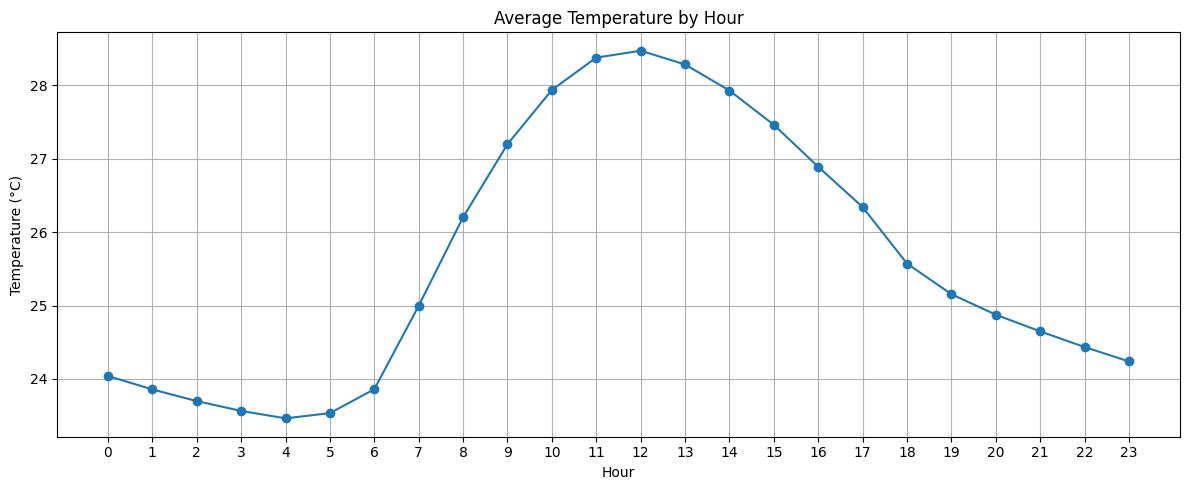

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_summary.index,
    hourly_summary["temperature_c"],
    marker="o"
)

plt.title(
    "Average Temperature by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

Hourly humidity

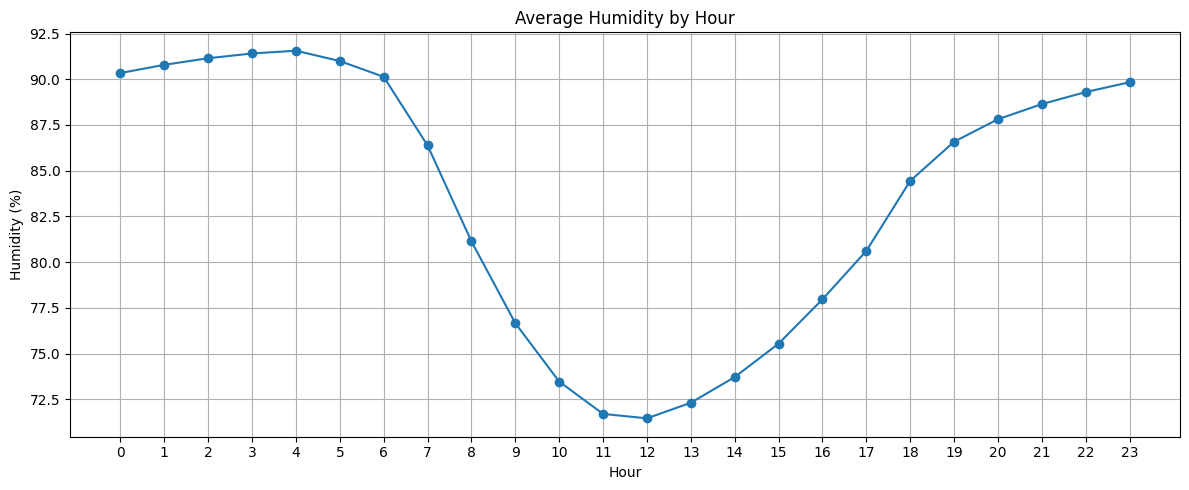

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_summary.index,
    hourly_summary["humidity_pct"],
    marker="o"
)

plt.title(
    "Average Humidity by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Humidity (%)")

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

Hourly rainfall

In [20]:
hourly_rainfall = (
    weather_df
    .groupby("hour")["rainfall_mm"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        rain_probability=lambda x: (
            x > 0
        ).mean() * 100
    )
)

display(hourly_rainfall)

,mean,median,maximum,rain_probability
hour,,,,
0,0.211270,0.0,27.0,30.011000
1,0.229014,0.0,28.5,31.691282
2,0.229864,0.0,28.6,32.992104
3,0.232085,0.0,30.0,33.706682
4,0.233133,0.0,25.0,33.675131
5,0.220707,0.0,33.6,33.041135
6,0.175424,0.0,24.0,28.996691
7,0.160957,0.0,24.3,30.690617
8,0.170682,0.0,32.1,37.305154


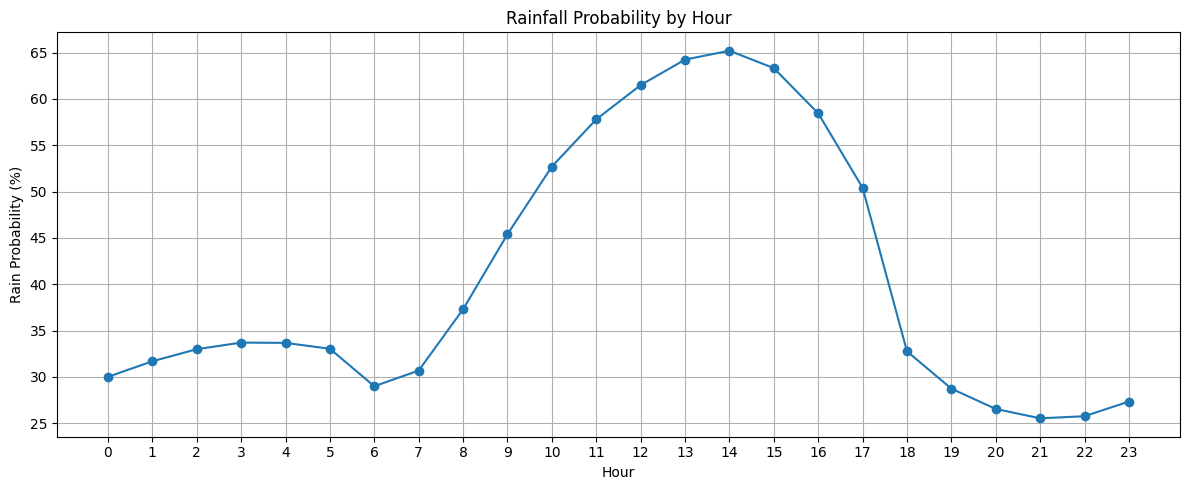

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_rainfall.index,
    hourly_rainfall["rain_probability"],
    marker="o"
)

plt.title(
    "Rainfall Probability by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Rain Probability (%)")

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

Monthly weather patterns

In [22]:
monthly_summary = (
    weather_df
    .groupby("month")
    [
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "rainfall_mm",
            "cloudcover_pct",
            "solarradiation_wm2"
        ]
    ]
    .mean()
)

display(monthly_summary)

,temperature_c,humidity_pct,pressure_hpa,windspeed_kmh,rainfall_mm,cloudcover_pct,solarradiation_wm2
month,,,,,,,
1,24.621253,82.284237,1011.540623,9.599625,0.192838,70.319141,209.695778
2,25.454215,77.468151,1011.729209,9.945373,0.082085,58.922322,252.681164
3,26.226297,78.502713,1010.907929,8.261864,0.127024,58.694696,256.734654
4,26.565612,82.381620,1010.034845,7.771656,0.241999,64.436360,248.352047
5,26.515532,85.377634,1008.711748,13.426485,0.418989,83.592154,209.152319
6,26.140245,84.482347,1009.131662,15.512171,0.277548,84.068573,217.714166
7,25.980955,83.959430,1008.868797,15.364003,0.265933,85.759589,213.396124
8,25.760839,83.841875,1009.520540,14.754857,0.252785,84.564347,226.871171
9,25.574075,85.015568,1009.725888,14.798900,0.329001,83.527393,217.628022


Monthly rainfall

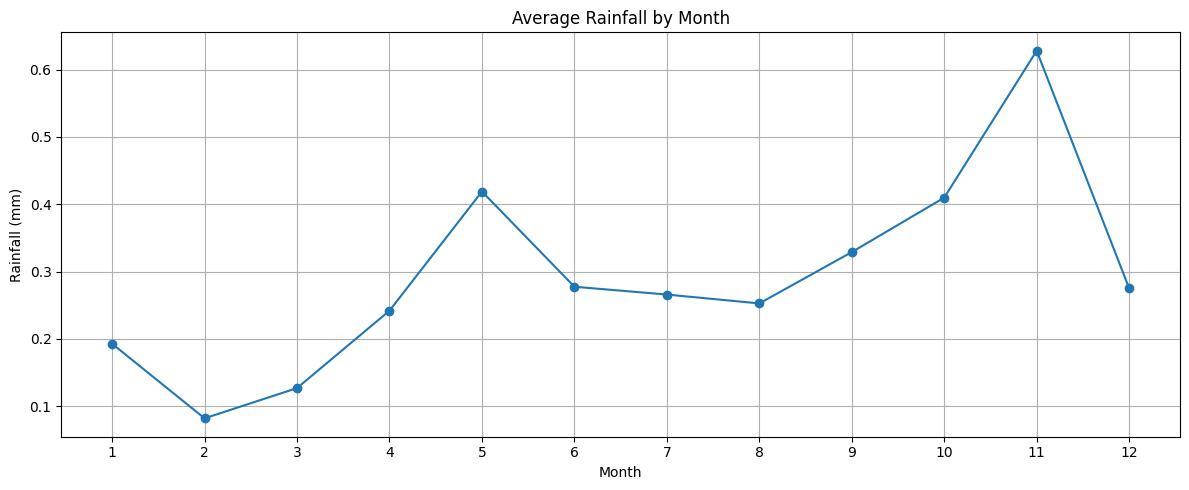

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary.index,
    monthly_summary["rainfall_mm"],
    marker="o"
)

plt.title(
    "Average Rainfall by Month"
)

plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()

Seasonal analysis

In [24]:
seasonal_summary = (
    weather_df
    .groupby("season")
    [
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "rainfall_mm",
            "cloudcover_pct"
        ]
    ]
    .mean()
)

display(seasonal_summary)

,temperature_c,humidity_pct,pressure_hpa,windspeed_kmh,rainfall_mm,cloudcover_pct
season,,,,,,
First_Intermonsoon,26.393173,80.410372,1010.478544,8.020778,0.183569,61.518465
Northeast_Monsoon,24.904802,81.691795,1011.424737,9.677376,0.186368,68.259010
Second_Intermonsoon,25.000321,86.667202,1010.363742,9.883157,0.517214,84.224447
Southwest_Monsoon,25.996122,84.532579,1009.188628,14.766260,0.308924,84.309005


Yearly rainfall trends

In [25]:
yearly_rainfall = (
    weather_df
    .groupby("year")["rainfall_mm"]
    .agg(
        mean="mean",
        median="median",
        maximum="max"
    )
)

display(yearly_rainfall)

,mean,median,maximum
year,,,
2020,0.240515,0.0,67.1
2021,0.301308,0.0,54.8
2022,0.262999,0.0,32.4
2023,0.322749,0.0,28.3
2024,0.314950,0.0,29.7
2025,0.312368,0.0,32.1


District weather comparison

In [26]:
district_weather = (
    weather_df
    .groupby("district")
    [
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "rainfall_mm",
            "cloudcover_pct",
            "solarradiation_wm2"
        ]
    ]
    .mean()
)

display(district_weather)

,temperature_c,humidity_pct,pressure_hpa,windspeed_kmh,rainfall_mm,cloudcover_pct,solarradiation_wm2
district,,,,,,,
Colombo,26.705223,83.900045,1009.734231,11.164334,0.340307,76.691042,217.037151
Galle,26.430571,84.905820,1009.867632,12.121717,0.336223,77.331341,219.797989
Gampaha,26.346987,84.407391,1009.780268,9.389071,0.358147,77.245979,212.808747
Jaffna,27.895300,78.653762,1008.965052,17.254009,0.162402,70.484093,232.320111
Kandy,23.019752,84.154794,1011.347751,9.403876,0.271239,78.488536,217.364920


District rainfall comparison

In [27]:
district_rainfall = (
    weather_df
    .groupby("district")["rainfall_mm"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        rain_probability=lambda x: (
            x > 0
        ).mean() * 100
    )
)

display(district_rainfall)

,mean,median,maximum,rain_probability
district,,,,
Colombo,0.340307,0.0,58.7,47.167040
Galle,0.336223,0.0,67.1,48.560072
Gampaha,0.358147,0.0,54.8,46.815067
Jaffna,0.162402,0.0,43.6,23.322443
Kandy,0.271239,0.0,43.1,37.578914


Point-level rainfall variation

In [28]:
point_rainfall = (
    weather_df
    .groupby(
        [
            "district",
            "global_pointid"
        ]
    )["rainfall_mm"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        rain_probability=lambda x: (
            x > 0
        ).mean() * 100
    )
    .reset_index()
)

display(
    point_rainfall.head(20)
)

,district,global_pointid,mean,median,maximum,rain_probability
0,Colombo,COL_001,0.337909,0.0,38.9,47.762698
1,Colombo,COL_002,0.346788,0.0,58.7,48.420392
2,Colombo,COL_003,0.346788,0.0,58.7,48.420392
3,Colombo,COL_004,0.321698,0.0,26.2,38.950350
4,Colombo,COL_005,0.337909,0.0,38.9,47.762698
5,Colombo,COL_006,0.337909,0.0,38.9,47.762698
6,Colombo,COL_007,0.337909,0.0,38.9,47.762698
7,Colombo,COL_008,0.401631,0.1,52.7,50.076034
8,Colombo,COL_009,0.324947,0.0,47.2,47.306493
9,Colombo,COL_010,0.324947,0.0,47.2,47.306493


Point-level temperature variation

In [29]:
point_temperature = (
    weather_df
    .groupby(
        [
            "district",
            "global_pointid"
        ]
    )["temperature_c"]
    .agg(
        mean="mean",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

display(
    point_temperature.head(20)
)

,district,global_pointid,mean,minimum,maximum
0,Colombo,COL_001,26.686441,18.3,35.5
1,Colombo,COL_002,26.615298,18.5,35.6
2,Colombo,COL_003,26.715298,18.6,35.7
3,Colombo,COL_004,27.367459,23.2,31.5
4,Colombo,COL_005,26.686441,18.3,35.5
5,Colombo,COL_006,26.636428,18.2,35.4
6,Colombo,COL_007,26.686441,18.3,35.5
7,Colombo,COL_008,26.340908,17.7,36.6
8,Colombo,COL_009,26.707636,18.4,36.2
9,Colombo,COL_010,26.657550,18.3,36.1


Spatial rainfall similarity

In [30]:
rainfall_point_matrix = (
    weather_df
    .pivot_table(
        index="datetime",
        columns="global_pointid",
        values="rainfall_mm"
    )
)

print(
    "Rainfall point matrix shape:",
    rainfall_point_matrix.shape
)

display(
    rainfall_point_matrix.head()
)

Rainfall point matrix shape: (52608, 107)


global_pointid,COL_001,COL_002,COL_003,COL_004,COL_005,COL_006,COL_007,COL_008,COL_009,COL_010,...,KAN_024,KAN_025,KAN_026,KAN_027,KAN_028,KAN_029,KAN_030,KAN_031,KAN_032,KAN_033
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 01:00:00,0.0,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 02:00:00,0.1,0.2,0.2,0.3,0.1,0.1,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:00:00,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Spatial rainfall correlation

In [31]:
rainfall_point_correlation = (
    rainfall_point_matrix
    .corr()
)

display(
    rainfall_point_correlation.iloc[:10, :10]
)

global_pointid,COL_001,COL_002,COL_003,COL_004,COL_005,COL_006,COL_007,COL_008,COL_009,COL_010
global_pointid,,,,,,,,,,
COL_001,1.000000,0.863384,0.863384,0.603390,1.000000,1.000000,1.000000,0.781648,0.827692,0.827692
COL_002,0.863384,1.000000,1.000000,0.581075,0.863384,0.863384,0.863384,0.731983,0.676517,0.676517
COL_003,0.863384,1.000000,1.000000,0.581075,0.863384,0.863384,0.863384,0.731983,0.676517,0.676517
COL_004,0.603390,0.581075,0.581075,1.000000,0.603390,0.603390,0.603390,0.480422,0.592760,0.592760
COL_005,1.000000,0.863384,0.863384,0.603390,1.000000,1.000000,1.000000,0.781648,0.827692,0.827692
COL_006,1.000000,0.863384,0.863384,0.603390,1.000000,1.000000,1.000000,0.781648,0.827692,0.827692
COL_007,1.000000,0.863384,0.863384,0.603390,1.000000,1.000000,1.000000,0.781648,0.827692,0.827692
COL_008,0.781648,0.731983,0.731983,0.480422,0.781648,0.781648,0.781648,1.000000,0.700485,0.700485
COL_009,0.827692,0.676517,0.676517,0.592760,0.827692,0.827692,0.827692,0.700485,1.000000,1.000000


Create geographical distance matrix

In [32]:
def haversine_distance(
    lat1,
    lon1,
    lat2,
    lon2
):
    """
    Calculate distance between two geographic
    coordinates in kilometres.
    """

    R = 6371.0

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = lat2 - lat1

    dlon = np.radians(
        lon2 - lon1
    )

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        *
        np.cos(lat2)
        *
        np.sin(dlon / 2) ** 2
    )

    c = (
        2 *
        np.arctan2(
            np.sqrt(a),
            np.sqrt(1 - a)
        )
    )

    return R * c

Calculate point distances

In [33]:
point_locations = (
    weather_df[
        [
            "global_pointid",
            "district",
            "latitude",
            "longitude"
        ]
    ]
    .drop_duplicates(
        "global_pointid"
    )
    .reset_index(drop=True)
)

distance_records = []

for i in range(
    len(point_locations)
):

    for j in range(
        i + 1,
        len(point_locations)
    ):

        p1 = point_locations.iloc[i]
        p2 = point_locations.iloc[j]

        distance = haversine_distance(
            p1["latitude"],
            p1["longitude"],
            p2["latitude"],
            p2["longitude"]
        )

        distance_records.append({

            "point1":
                p1["global_pointid"],

            "point2":
                p2["global_pointid"],

            "district1":
                p1["district"],

            "district2":
                p2["district"],

            "distance_km":
                distance
        })

distance_df = pd.DataFrame(
    distance_records
)

display(
    distance_df.head()
)

,point1,point2,district1,district2,distance_km
0,COL_001,COL_002,Colombo,Colombo,7.472902
1,COL_001,COL_003,Colombo,Colombo,14.945803
2,COL_001,COL_004,Colombo,Colombo,10.565912
3,COL_001,COL_005,Colombo,Colombo,7.471187
4,COL_001,COL_006,Colombo,Colombo,10.566692


Spatial similarity vs distance

In [34]:
records = []

for _, row in distance_df.iterrows():

    p1 = row["point1"]
    p2 = row["point2"]

    if (
        p1 in rainfall_point_correlation.columns
        and
        p2 in rainfall_point_correlation.columns
    ):

        correlation = (
            rainfall_point_correlation
            .loc[p1, p2]
        )

        records.append({

            "point1":
                p1,

            "point2":
                p2,

            "distance_km":
                row["distance_km"],

            "rainfall_correlation":
                correlation
        })

spatial_similarity = pd.DataFrame(
    records
)

display(
    spatial_similarity.head()
)

,point1,point2,distance_km,rainfall_correlation
0,COL_001,COL_002,7.472902,0.863384
1,COL_001,COL_003,14.945803,0.863384
2,COL_001,COL_004,10.565912,0.603390
3,COL_001,COL_005,7.471187,1.000000
4,COL_001,COL_006,10.566692,1.000000


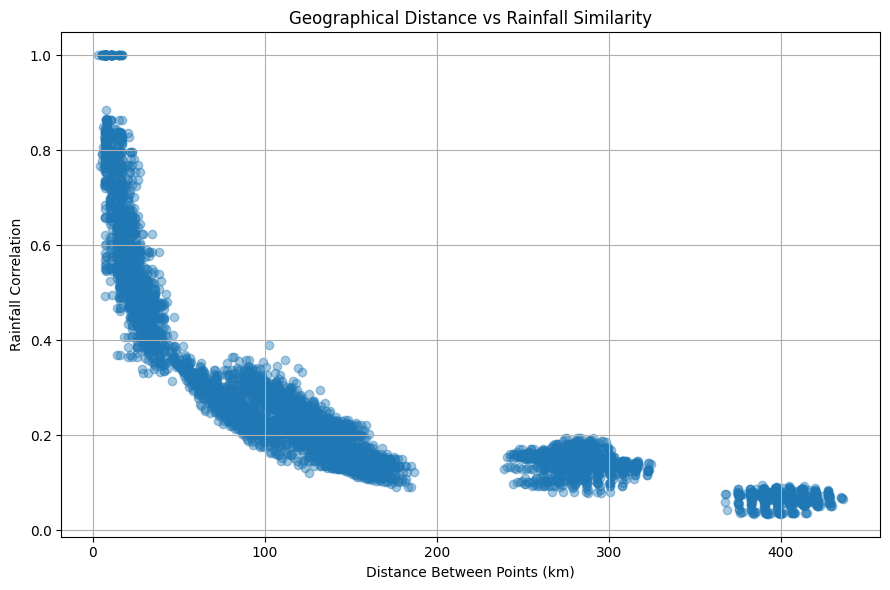

In [35]:
plt.figure(figsize=(9, 6))

plt.scatter(
    spatial_similarity["distance_km"],
    spatial_similarity["rainfall_correlation"],
    alpha=0.4
)

plt.title(
    "Geographical Distance vs Rainfall Similarity"
)

plt.xlabel(
    "Distance Between Points (km)"
)

plt.ylabel(
    "Rainfall Correlation"
)

plt.grid(True)

plt.tight_layout()
plt.show()

Temporal dependency: rainfall autocorrelation

In [36]:
lags = [
    1,
    2,
    3,
    6,
    12,
    24
]

autocorrelation_results = []

for lag in lags:

    correlations = []

    for point_id, group in weather_df.groupby(
        "global_pointid"
    ):

        series = (
            group
            .sort_values("datetime")
            ["rainfall_mm"]
        )

        correlation = (
            series
            .autocorr(lag=lag)
        )

        correlations.append(
            correlation
        )

    autocorrelation_results.append({

        "lag_hours":
            lag,

        "mean_autocorrelation":
            np.nanmean(
                correlations
            )
    })

autocorrelation_df = pd.DataFrame(
    autocorrelation_results
)

display(
    autocorrelation_df
)

,lag_hours,mean_autocorrelation
0,1,0.499417
1,2,0.358727
2,3,0.291510
3,6,0.174205
4,12,0.115475
5,24,0.177798


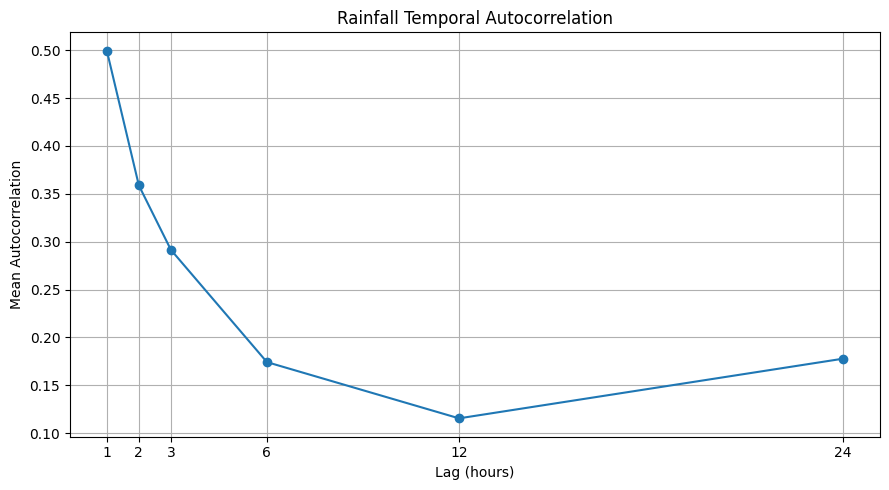

In [37]:
plt.figure(figsize=(9, 5))

plt.plot(
    autocorrelation_df["lag_hours"],
    autocorrelation_df["mean_autocorrelation"],
    marker="o"
)

plt.title(
    "Rainfall Temporal Autocorrelation"
)

plt.xlabel("Lag (hours)")
plt.ylabel("Mean Autocorrelation")

plt.xticks(lags)
plt.grid(True)

plt.tight_layout()
plt.show()

Temporal dependency of other variables

In [38]:
variables_for_autocorrelation = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "windspeed_kmh",
    "rainfall_mm",
    "cloudcover_pct"
]

lag_values = [
    1,
    3,
    6,
    12,
    24
]

autocorrelation_summary = []

for variable in variables_for_autocorrelation:

    for lag in lag_values:

        correlations = []

        for point_id, group in weather_df.groupby(
            "global_pointid"
        ):

            series = (
                group
                .sort_values("datetime")
                [variable]
            )

            correlations.append(
                series.autocorr(
                    lag=lag
                )
            )

        autocorrelation_summary.append({

            "variable":
                variable,

            "lag_hours":
                lag,

            "mean_autocorrelation":
                np.nanmean(
                    correlations
                )
        })

autocorrelation_summary = pd.DataFrame(
    autocorrelation_summary
)

display(
    autocorrelation_summary
)

,variable,lag_hours,mean_autocorrelation
0,temperature_c,1,0.945046
1,temperature_c,3,0.694594
2,temperature_c,6,0.189194
3,temperature_c,12,-0.311121
4,temperature_c,24,0.888437
5,humidity_pct,1,0.935475
6,humidity_pct,3,0.691689
7,humidity_pct,6,0.240603
8,humidity_pct,12,-0.215909
9,humidity_pct,24,0.805938


Correlation between weather variables

In [39]:
correlation_variables = [
    "temperature_c",
    "feelslike_c",
    "humidity_pct",
    "dewpoint_c",
    "pressure_hpa",
    "windspeed_kmh",
    "winddirection_deg",
    "windgust_kmh",
    "rainfall_mm",
    "cloudcover_pct",
    "solarradiation_wm2",
    "sunshineduration_s"
]

correlation_variables = [
    col for col in correlation_variables
    if col in weather_df.columns
]

correlation_matrix = (
    weather_df[
        correlation_variables
    ]
    .corr()
)

display(
    correlation_matrix
)

,temperature_c,feelslike_c,humidity_pct,dewpoint_c,pressure_hpa,windspeed_kmh,winddirection_deg,windgust_kmh,rainfall_mm,cloudcover_pct,solarradiation_wm2,sunshineduration_s
temperature_c,1.000000,0.941477,-0.683461,0.595279,-0.391329,0.372052,0.183920,0.270494,-0.047256,-0.108002,0.580859,0.532896
feelslike_c,0.941477,1.000000,-0.489702,0.720980,-0.360984,0.116263,0.169870,0.020796,-0.027954,-0.096029,0.498928,0.435176
humidity_pct,-0.683461,-0.489702,1.000000,0.168824,0.063735,-0.287463,-0.034995,-0.334814,0.126270,0.212514,-0.711598,-0.649752
dewpoint_c,0.595279,0.720980,0.168824,1.000000,-0.452902,0.219335,0.219987,0.028459,0.068505,0.083434,0.008986,0.029898
pressure_hpa,-0.391329,-0.360984,0.063735,-0.452902,1.000000,-0.358668,-0.301202,-0.290796,-0.071213,-0.152436,-0.040192,-0.037548
windspeed_kmh,0.372052,0.116263,-0.287463,0.219335,-0.358668,1.000000,0.217389,0.865431,0.020999,0.069645,0.245995,0.229740
winddirection_deg,0.183920,0.169870,-0.034995,0.219987,-0.301202,0.217389,1.000000,0.270178,0.076433,0.158288,0.148442,0.128055
windgust_kmh,0.270494,0.020796,-0.334814,0.028459,-0.290796,0.865431,0.270178,1.000000,0.086685,0.111503,0.376342,0.355080
rainfall_mm,-0.047256,-0.027954,0.126270,0.068505,-0.071213,0.020999,0.076433,0.086685,1.000000,0.167023,0.011456,-0.022328
cloudcover_pct,-0.108002,-0.096029,0.212514,0.083434,-0.152436,0.069645,0.158288,0.111503,0.167023,1.000000,-0.094179,-0.128747


Correlations specifically with rainfall

In [40]:
rainfall_correlations = (
    correlation_matrix[
        "rainfall_mm"
    ]
    .drop("rainfall_mm")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    rainfall_correlations.to_frame(
        "Correlation_with_Rainfall"
    )
)

,Correlation_with_Rainfall
cloudcover_pct,0.167023
humidity_pct,0.126270
windgust_kmh,0.086685
winddirection_deg,0.076433
pressure_hpa,-0.071213
dewpoint_c,0.068505
temperature_c,-0.047256
feelslike_c,-0.027954
sunshineduration_s,-0.022328
windspeed_kmh,0.020999


Short-term forecastability-We want to investigate whether weather at time t has a relationship with rainfall at:

In [41]:
forecast_df = (
    weather_df
    .sort_values(
        [
            "global_pointid",
            "datetime"
        ]
    )
    .copy()
)

for horizon in [1, 2, 3]:

    forecast_df[
        f"rainfall_t_plus_{horizon}"
    ] = (
        forecast_df
        .groupby(
            "global_pointid"
        )["rainfall_mm"]
        .shift(-horizon)
    )

display(
    forecast_df[
        [
            "global_pointid",
            "datetime",
            "rainfall_mm",
            "rainfall_t_plus_1",
            "rainfall_t_plus_2",
            "rainfall_t_plus_3"
        ]
    ].head(20)
)

,global_pointid,datetime,rainfall_mm,rainfall_t_plus_1,rainfall_t_plus_2,rainfall_t_plus_3
0,COL_001,2020-01-01 00:00:00,0.1,0.0,0.1,0.1
1,COL_001,2020-01-01 01:00:00,0.0,0.1,0.1,0.0
2,COL_001,2020-01-01 02:00:00,0.1,0.1,0.0,0.0
3,COL_001,2020-01-01 03:00:00,0.1,0.0,0.0,0.0
4,COL_001,2020-01-01 04:00:00,0.0,0.0,0.0,0.0
5,COL_001,2020-01-01 05:00:00,0.0,0.0,0.0,0.0
6,COL_001,2020-01-01 06:00:00,0.0,0.0,0.0,0.0
7,COL_001,2020-01-01 07:00:00,0.0,0.0,0.0,0.0
8,COL_001,2020-01-01 08:00:00,0.0,0.0,0.0,0.0
9,COL_001,2020-01-01 09:00:00,0.0,0.0,0.0,0.0


Current rainfall vs future rainfall

In [42]:
future_correlations = {}

for horizon in [1, 2, 3]:

    future_correlations[
        f"t+{horizon}"
    ] = (
        forecast_df[
            [
                "rainfall_mm",
                f"rainfall_t_plus_{horizon}"
            ]
        ]
        .corr()
        .iloc[0, 1]
    )

future_correlation_df = pd.DataFrame(
    {
        "Forecast_Horizon":
            list(future_correlations.keys()),

        "Correlation":
            list(future_correlations.values())
    }
)

display(
    future_correlation_df
)

,Forecast_Horizon,Correlation
0,t+1,0.496326
1,t+2,0.356471
2,t+3,0.287883


Rainfall persistence

In [43]:
rain_persistence = []

for horizon in [1, 2, 3]:

    current_rain = (
        forecast_df["rainfall_mm"] > 0
    )

    future_rain = (
        forecast_df[
            f"rainfall_t_plus_{horizon}"
        ] > 0
    )

    valid = (
        current_rain
        &
        forecast_df[
            f"rainfall_t_plus_{horizon}"
        ].notna()
    )

    probability = (
        future_rain[valid]
        .groupby(
            current_rain[valid]
        )
        .mean()
    )

    rain_persistence.append({

        "Horizon":
            f"{horizon} hour",

        "P(Rain future | No rain now)":
            probability.get(
                False,
                np.nan
            ),

        "P(Rain future | Rain now)":
            probability.get(
                True,
                np.nan
            )
    })

rain_persistence_df = pd.DataFrame(
    rain_persistence
)

display(
    rain_persistence_df
)

,Horizon,P(Rain future | No rain now),P(Rain future | Rain now)
0,1 hour,NaN,0.827842
1,2 hour,NaN,0.749601
2,3 hour,NaN,0.698373


Future rainfall relationship with current weather

In [44]:
predictor_variables = [
    "temperature_c",
    "humidity_pct",
    "dewpoint_c",
    "pressure_hpa",
    "windspeed_kmh",
    "windgust_kmh",
    "cloudcover_pct",
    "solarradiation_wm2",
    "rainfall_mm"
]

forecast_relationships = []

for horizon in [1, 2, 3]:

    target = (
        f"rainfall_t_plus_{horizon}"
    )

    for variable in predictor_variables:

        correlation = (
            forecast_df[
                [
                    variable,
                    target
                ]
            ]
            .corr()
            .iloc[0, 1]
        )

        forecast_relationships.append({

            "Horizon":
                f"t+{horizon}",

            "Variable":
                variable,

            "Correlation":
                correlation
        })

forecast_relationships_df = pd.DataFrame(
    forecast_relationships
)

display(
    forecast_relationships_df
)

,Horizon,Variable,Correlation
0,t+1,temperature_c,0.005205
1,t+1,humidity_pct,0.069991
2,t+1,dewpoint_c,0.080657
3,t+1,pressure_hpa,-0.069061
4,t+1,windspeed_kmh,0.021192
5,t+1,windgust_kmh,0.073981
6,t+1,cloudcover_pct,0.156642
7,t+1,solarradiation_wm2,0.058161
8,t+1,rainfall_mm,0.496326
9,t+2,temperature_c,0.020096


Extreme rainfall

In [45]:
rainfall_quantiles = (
    weather_df[
        "rainfall_mm"
    ]
    .quantile(
        [0.90, 0.95, 0.99]
    )
)

display(
    rainfall_quantiles.to_frame(
        "Rainfall_mm"
    )
)

,Rainfall_mm
0.90,0.7
0.95,1.5
0.99,4.5


In [46]:
extreme_threshold = (
    rainfall_quantiles.loc[0.99]
)

extreme_rainfall = weather_df[
    weather_df["rainfall_mm"]
    >= extreme_threshold
]

print(
    "Extreme rainfall threshold:",
    extreme_threshold,
    "mm"
)

print(
    "Number of extreme observations:",
    len(extreme_rainfall)
)

display(
    extreme_rainfall[
        [
            "district",
            "global_pointid",
            "datetime",
            "rainfall_mm",
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "cloudcover_pct"
        ]
    ]
    .sort_values(
        "rainfall_mm",
        ascending=False
    )
    .head(20)
)

Extreme rainfall threshold: 4.5 mm
Number of extreme observations: 58174


,district,global_pointid,datetime,rainfall_mm,temperature_c,humidity_pct,pressure_hpa,windspeed_kmh,cloudcover_pct
1638477,Galle,GAL_021,2020-11-13 21:00:00,67.1,24.9,95,1011.1,2.0,100
796750,Galle,GAL_005,2020-11-13 22:00:00,63.5,25.3,94,1011.1,2.9,100
1007182,Galle,GAL_009,2020-11-13 22:00:00,63.5,25.3,94,1011.1,2.9,100
1059790,Galle,GAL_010,2020-11-13 22:00:00,63.5,25.2,94,1011.1,2.9,100
849358,Galle,GAL_006,2020-11-13 22:00:00,63.5,25.3,94,1011.1,2.9,100
744142,Galle,GAL_004,2020-11-13 22:00:00,63.5,25.3,94,1011.1,2.9,100
1375437,Galle,GAL_016,2020-11-13 21:00:00,61.9,24.9,97,1011.2,1.3,100
1638476,Galle,GAL_021,2020-11-13 20:00:00,61.9,24.9,95,1010.6,4.3,100
60407,Colombo,COL_002,2020-11-20 23:00:00,58.7,24.5,94,1012.0,15.0,100
113015,Colombo,COL_003,2020-11-20 23:00:00,58.7,24.6,94,1012.0,15.0,100


Check data suitability for LSTM/GRU

In [47]:
point_sequence_summary = (
    weather_df
    .groupby(
        [
            "district",
            "global_pointid"
        ]
    )
    .agg(
        observations=(
            "datetime",
            "count"
        ),

        start_time=(
            "datetime",
            "min"
        ),

        end_time=(
            "datetime",
            "max"
        ),

        missing_rainfall=(
            "rainfall_mm",
            lambda x: x.isna().sum()
        )
    )
    .reset_index()
)

display(
    point_sequence_summary.head(20)
)

,district,global_pointid,observations,start_time,end_time,missing_rainfall
0,Colombo,COL_001,52608,2020-01-01,2025-12-31 23:00:00,0
1,Colombo,COL_002,52608,2020-01-01,2025-12-31 23:00:00,0
2,Colombo,COL_003,52608,2020-01-01,2025-12-31 23:00:00,0
3,Colombo,COL_004,52608,2020-01-01,2025-12-31 23:00:00,0
4,Colombo,COL_005,52608,2020-01-01,2025-12-31 23:00:00,0
5,Colombo,COL_006,52608,2020-01-01,2025-12-31 23:00:00,0
6,Colombo,COL_007,52608,2020-01-01,2025-12-31 23:00:00,0
7,Colombo,COL_008,52608,2020-01-01,2025-12-31 23:00:00,0
8,Colombo,COL_009,52608,2020-01-01,2025-12-31 23:00:00,0
9,Colombo,COL_010,52608,2020-01-01,2025-12-31 23:00:00,0


Save EDA outputs

In [48]:
EDA_DIR = (
    "/content/drive/MyDrive/"
    "Capstone_Datasets/"
    "EDA_Results"
)

import os

os.makedirs(
    EDA_DIR,
    exist_ok=True
)

district_weather.to_csv(
    os.path.join(
        EDA_DIR,
        "district_weather_summary.csv"
    )
)

district_rainfall.to_csv(
    os.path.join(
        EDA_DIR,
        "district_rainfall_summary.csv"
    )
)

point_rainfall.to_csv(
    os.path.join(
        EDA_DIR,
        "point_rainfall_summary.csv"
    ),
    index=False
)

spatial_similarity.to_csv(
    os.path.join(
        EDA_DIR,
        "spatial_rainfall_similarity.csv"
    ),
    index=False
)

autocorrelation_summary.to_csv(
    os.path.join(
        EDA_DIR,
        "temporal_autocorrelation.csv"
    ),
    index=False
)

future_correlation_df.to_csv(
    os.path.join(
        EDA_DIR,
        "future_rainfall_correlation.csv"
    ),
    index=False
)

rain_persistence_df.to_csv(
    os.path.join(
        EDA_DIR,
        "rainfall_persistence.csv"
    ),
    index=False
)

forecast_relationships_df.to_csv(
    os.path.join(
        EDA_DIR,
        "forecast_relationships.csv"
    ),
    index=False
)

print("EDA results saved successfully.")
print(EDA_DIR)

EDA results saved successfully.
/content/drive/MyDrive/Capstone_Datasets/EDA_Results
